# Problem Statement
To predict which passengers were transported to another dimension (unsafe) and who remained in the spaceship (safe) after a spacetime anomaly.

### Importing Libraries

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [79]:
data_frame = pd.read_csv('./data/spaceship_titanic.csv')
data_frame.sample(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
7305,7815_01,Earth,False,F/1496/S,PSO J318.5-22,27.0,False,0.0,605.0,0.0,0.0,0.0,Jaye Daviddley,True
5897,6252_01,Mars,False,F/1201/S,TRAPPIST-1e,54.0,False,630.0,298.0,418.0,312.0,0.0,Gork Chort,False
7311,7828_01,Earth,True,G/1266/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,Jimmyn Deckley,False


In [80]:
data_frame.shape

(8693, 14)

In [81]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [82]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [83]:
spending_subset = data_frame.loc[:, 'RoomService' : 'VRDeck'].columns
data_frame.groupby('VIP')[spending_subset].mean()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
VIP,,,,,
False,217.218527,426.336536,173.876298,301.711045,282.718056
True,473.615385,1811.393782,247.726804,760.710660,1234.856410


#### VIP spends more than regular people

In [84]:
data_frame.groupby('CryoSleep')[spending_subset].mean()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
CryoSleep,,,,,
False,350.146772,713.004316,270.586504,486.09294,475.716165
True,0.000000,0.000000,0.000000,0.00000,0.000000


#### Prople in deepsleep is not spending any money on spaceship servies.
Therefore wherever CryoSleep is True their spending should be 0 and vice-versa.

In [85]:
temporary_subset = data_frame['CryoSleep'] == True
data_frame.loc[temporary_subset, spending_subset] = 0.0

In [86]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
dtype: int64

In [87]:
for spends in spending_subset:
    for value in [True, False]:
        temporary_subset = data_frame['VIP'] == value
        k = data_frame.loc[temporary_subset, spends].astype(float).mean()
        data_frame.loc[temporary_subset, spends] = data_frame.loc[temporary_subset, spends].fillna(k)

In [88]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

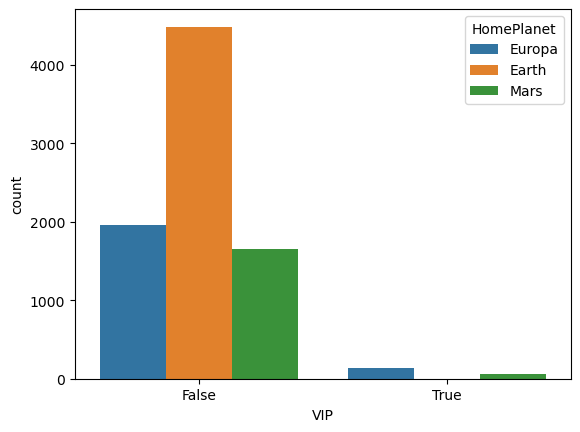

In [89]:
sb.countplot(data=data_frame, x='VIP', hue='HomePlanet')
plt.show()

In [90]:
col = 'HomePlanet'
temp = data_frame['VIP'] == False
data_frame.loc[temp, col] = data_frame.loc[temp, col].fillna('Earth')

temp = data_frame['VIP'] == True
data_frame.loc[temp, col] = data_frame.loc[temp, col].fillna('Europa')



In [91]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet        3
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

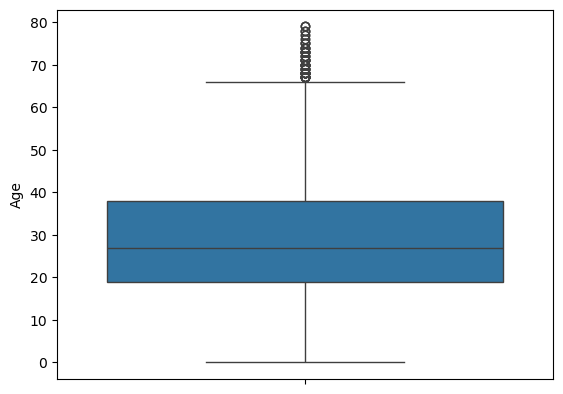

In [94]:
sb.boxplot(data_frame['Age'])
plt.show()

In [95]:
temp = data_frame[data_frame['Age'] < 60]['Age'].mean()
data_frame['Age'] = data_frame['Age'].fillna(temp)

In [96]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet        3
CryoSleep       217
Cabin           199
Destination     182
Age               0
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

In [98]:
mask = (data_frame[spending_subset] > 0).any(axis=1)
data_frame.loc[mask, 'CryoSleep'] = False

In [99]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet        3
CryoSleep        88
Cabin           199
Destination     182
Age               0
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

In [101]:
for col in data_frame.columns:
    if (data_frame[col].isnull().sum() == 0):
        continue

    if (data_frame[col].dtype == object or data_frame[col].dtype == bool):
        data_frame[col] = data_frame[col].fillna(data_frame[col].mode()[0])
    else:
        data_frame[col] = data_frame[col].fillna(data_frame[col].mean())

C:\Users\arjit\AppData\Local\Temp\ipykernel_16896\4011992577.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame[col] = data_frame[col].fillna(data_frame[col].mode()[0])


In [102]:
data_frame.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64